In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp0_group"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedGroupKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
groups = df['lesion_id'].values 

# BERUBAH: Menggunakan StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified K-Fold siap!


In [4]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# =========================================================
# CELL 4: MODEL ARCHITECTURE (Baseline ConvNeXt Tanpa Attention)
# =========================================================

class ConvNeXt_Baseline(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_Baseline, self).__init__()
        # Load pre-trained ConvNeXt-Tiny
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        
        # Ekstrak feature extractor
        self.features = convnext.features
        
        # TIDAK ADA ATTENTION BLOCK DI SINI
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier (Flatten diletakkan sebelum LayerNorm)
        self.classifier = nn.Sequential(
            nn.Flatten(1),                     # Ubah dari (Batch, 768, 1, 1) menjadi (Batch, 768)
            nn.LayerNorm(768, eps=1e-6),       # LayerNorm menerima bentuk yang benar
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # x = self.se_block(x)  <-- DIHAPUS
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Test inisialisasi model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_test = ConvNeXt_Baseline().to(device)
print(f"Total parameter Baseline: {sum(p.numel() for p in model_test.parameters())}")

Total parameter Baseline: 27825511


In [5]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Simpan metrik
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # Simpan model terbaik (.pth)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp0_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa hardware
    end_time = time.time()
    training_time = end_time - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # Dalam MB
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp0_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time, max_memory

In [6]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp0_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp0_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp0_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp0_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp0_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 0: ConvNeXt Baseline + Focal Loss Group
Menyimpan di folder: results_exp0_group

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.4086 Acc: 0.7488 | Val Loss: 0.2925 Acc: 0.8098
Epoch 2/50 - Train Loss: 0.2147 Acc: 0.8324 | Val Loss: 0.2318 Acc: 0.8252
Epoch 3/50 - Train Loss: 0.1489 Acc: 0.8741 | Val Loss: 0.2341 Acc: 0.8312
Epoch 4/50 - Train Loss: 0.1087 Acc: 0.8935 | Val Loss: 0.2253 Acc: 0.8451
Epoch 5/50 - Train Loss: 0.0738 Acc: 0.9265 | Val Loss: 0.2127 Acc: 0.8535
Epoch 6/50 - Train Loss: 0.0611 Acc: 0.9346 | Val Loss: 0.3141 Acc: 0.7781
Epoch 7/50 - Train Loss: 0.0825 Acc: 0.9174 | Val Loss: 0.2297 Acc: 0.8486
Epoch 8/50 - Train Loss: 0.0456 Acc: 0.9490 | Val Loss: 0.2628 Acc: 0.8242
Epoch 9/50 - Train Loss: 0.0311 Acc: 0.9635 | Val Loss: 0.2517 Acc: 0.8371
Epoch 10/50 - Train Loss: 0.0251 Acc: 0.9719 | Val Loss: 0.2888 Acc: 0.8431
Epoch 11/50 - Train Loss: 0.0240 Acc: 0.9756 | Val Loss: 0.2893 Acc: 0.8451
Epoch 12/50 - Train Loss: 0.0235 Acc: 0.9758 | Val

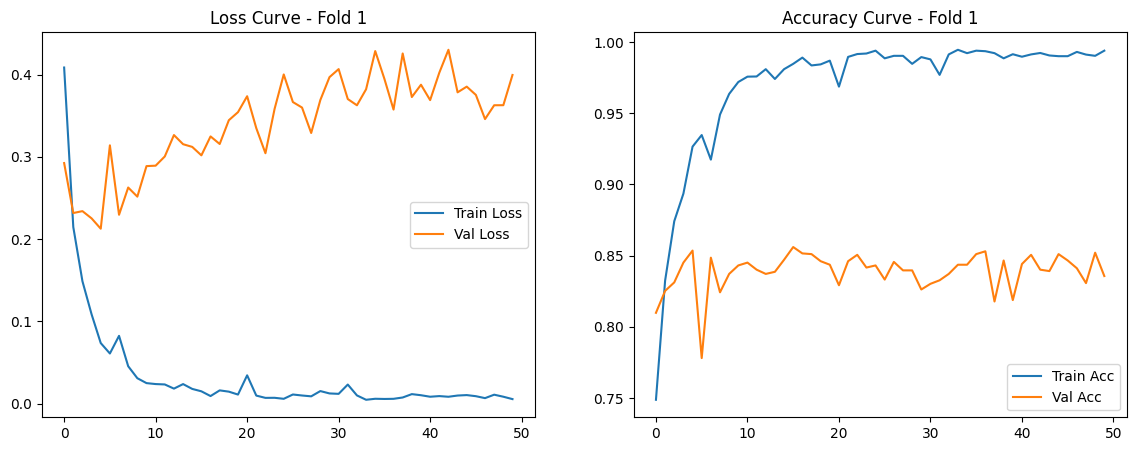

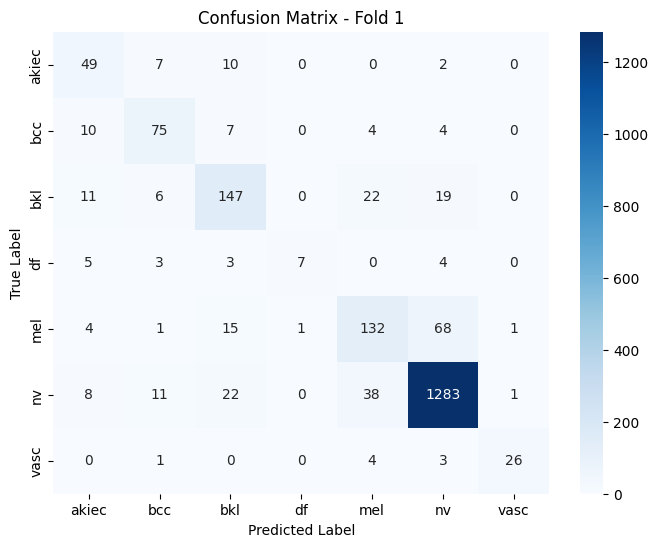

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp0_group

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.4576 Acc: 0.7251 | Val Loss: 0.2833 Acc: 0.7982
Epoch 2/50 - Train Loss: 0.2242 Acc: 0.8315 | Val Loss: 0.2327 Acc: 0.8297
Epoch 3/50 - Train Loss: 0.1610 Acc: 0.8651 | Val Loss: 0.2286 Acc: 0.8363
Epoch 4/50 - Train Loss: 0.1080 Acc: 0.8995 | Val Loss: 0.1913 Acc: 0.8533
Epoch 5/50 - Train Loss: 0.0865 Acc: 0.9186 | Val Loss: 0.1942 Acc: 0.8633
Epoch 6/50 - Train Loss: 0.0596 Acc: 0.9400 | Val Loss: 0.2151 Acc: 0.8508
Epoch 7/50 - Train Loss: 0.0520 Acc: 0.9470 | Val Loss: 0.2024 Acc: 0.8658
Epoch 8/50 - Train Loss: 0.0425 Acc: 0.9527 | Val Loss: 0.2425 Acc: 0.8448
Epoch 9/50 - Train Loss: 0.0369 Acc: 0.9597 | Val Loss: 0.2192 Acc: 0.8628
Epoch 10/50 - Train Loss: 0.0306 Acc: 0.9684 | Val Loss: 0.2412 Acc: 0.8513
Epoch 11/50 - Train Loss: 0.0255 Acc: 0.9732 | Val Loss: 0.2303 Acc: 0.8533
Epoch 12/50 - Train Loss: 0.0228 Acc: 0.9767 | Val Loss: 0.2709 A

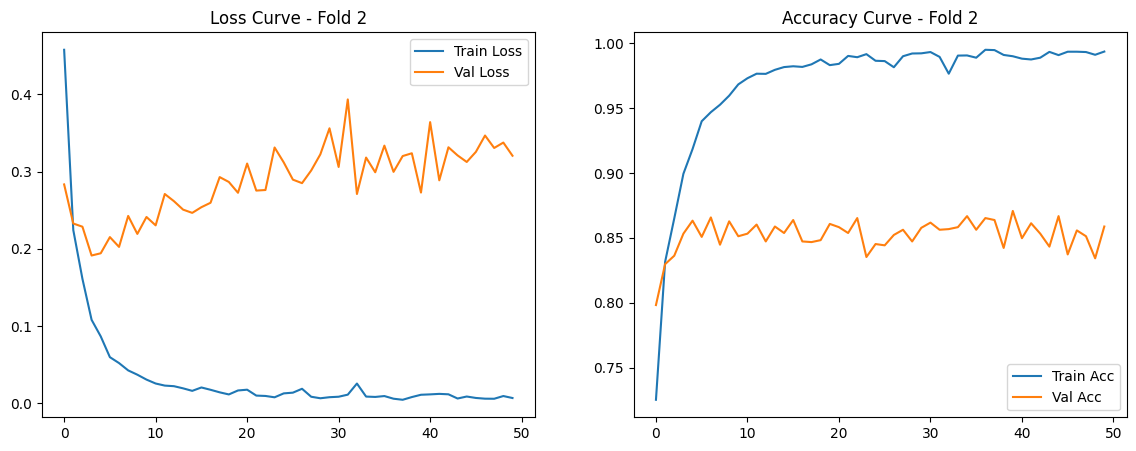

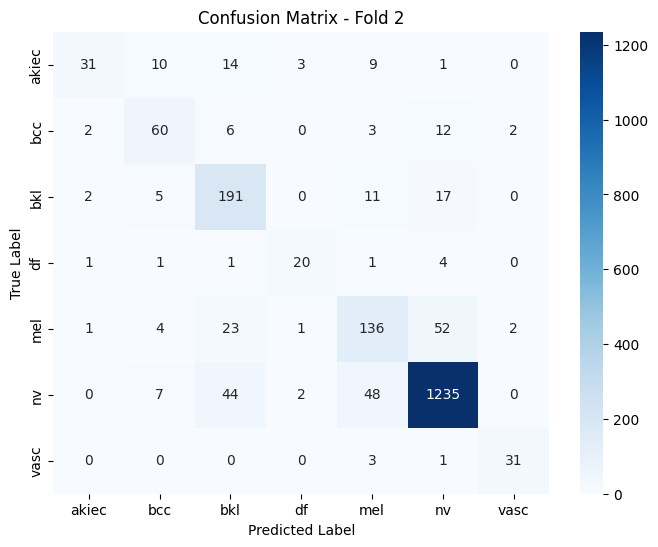

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp0_group

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3852 Acc: 0.7543 | Val Loss: 0.2484 Acc: 0.8164
Epoch 2/50 - Train Loss: 0.2005 Acc: 0.8426 | Val Loss: 0.2218 Acc: 0.8119
Epoch 3/50 - Train Loss: 0.1433 Acc: 0.8777 | Val Loss: 0.2327 Acc: 0.8448
Epoch 4/50 - Train Loss: 0.0943 Acc: 0.9118 | Val Loss: 0.2154 Acc: 0.8473
Epoch 5/50 - Train Loss: 0.0771 Acc: 0.9243 | Val Loss: 0.2190 Acc: 0.8527
Epoch 6/50 - Train Loss: 0.0557 Acc: 0.9432 | Val Loss: 0.2453 Acc: 0.8478
Epoch 7/50 - Train Loss: 0.0422 Acc: 0.9575 | Val Loss: 0.2458 Acc: 0.8537
Epoch 8/50 - Train Loss: 0.0384 Acc: 0.9613 | Val Loss: 0.2484 Acc: 0.8502
Epoch 9/50 - Train Loss: 0.0256 Acc: 0.9728 | Val Loss: 0.2805 Acc: 0.8458
Epoch 10/50 - Train Loss: 0.0201 Acc: 0.9776 | Val Loss: 0.2852 Acc: 0.8567
Epoch 11/50 - Train Loss: 0.0224 Acc: 0.9759 | Val Loss: 0.2783 Acc: 0.8592
Epoch 12/50 - Train Loss: 0.0298 Acc: 0.9691 | Val Loss: 0.2972 A

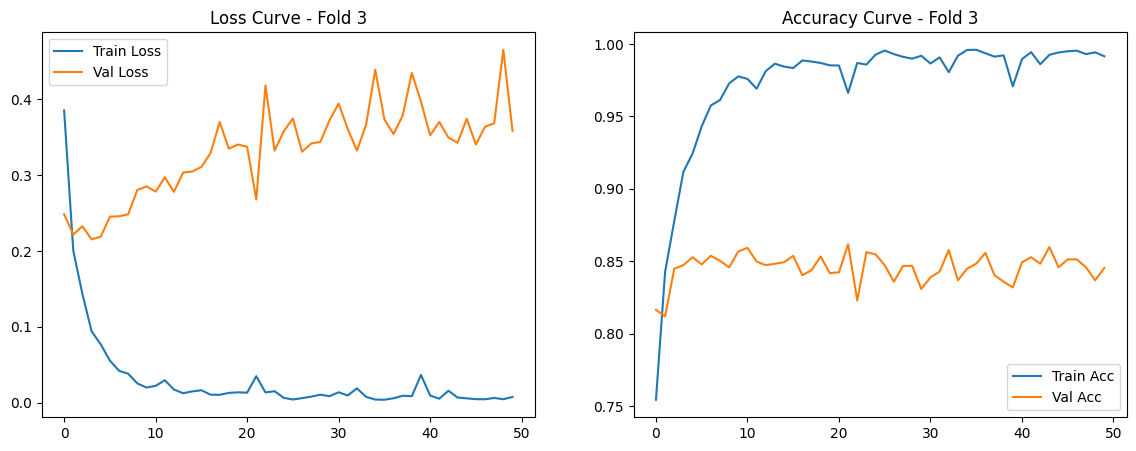

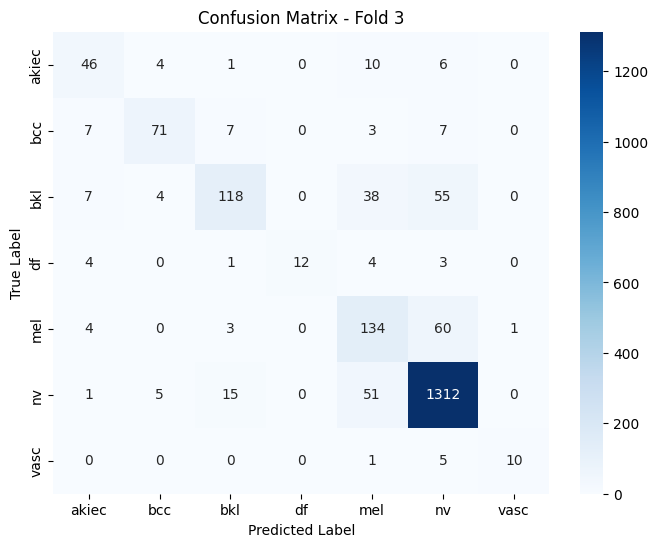

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp0_group

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.3711 Acc: 0.7647 | Val Loss: 0.2939 Acc: 0.7984
Epoch 2/50 - Train Loss: 0.1979 Acc: 0.8454 | Val Loss: 0.2415 Acc: 0.8168
Epoch 3/50 - Train Loss: 0.1382 Acc: 0.8826 | Val Loss: 0.2318 Acc: 0.8203
Epoch 4/50 - Train Loss: 0.0957 Acc: 0.9114 | Val Loss: 0.2625 Acc: 0.8128
Epoch 5/50 - Train Loss: 0.0814 Acc: 0.9234 | Val Loss: 0.2673 Acc: 0.8222
Epoch 6/50 - Train Loss: 0.0531 Acc: 0.9468 | Val Loss: 0.2375 Acc: 0.8366
Epoch 7/50 - Train Loss: 0.0372 Acc: 0.9629 | Val Loss: 0.2618 Acc: 0.8371
Epoch 8/50 - Train Loss: 0.0297 Acc: 0.9704 | Val Loss: 0.2616 Acc: 0.8431
Epoch 9/50 - Train Loss: 0.0372 Acc: 0.9585 | Val Loss: 0.2348 Acc: 0.8327
Epoch 10/50 - Train Loss: 0.0231 Acc: 0.9751 | Val Loss: 0.2443 Acc: 0.8456
Epoch 11/50 - Train Loss: 0.0235 Acc: 0.9760 | Val Loss: 0.2552 Acc: 0.8476
Epoch 12/50 - Train Loss: 0.0240 Acc: 0.9761 | Val Loss: 0.3014 A

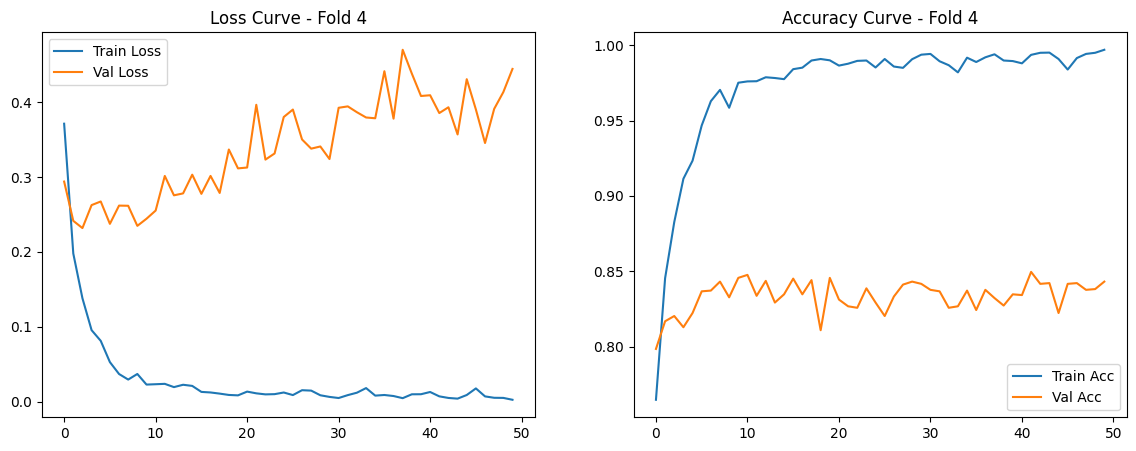

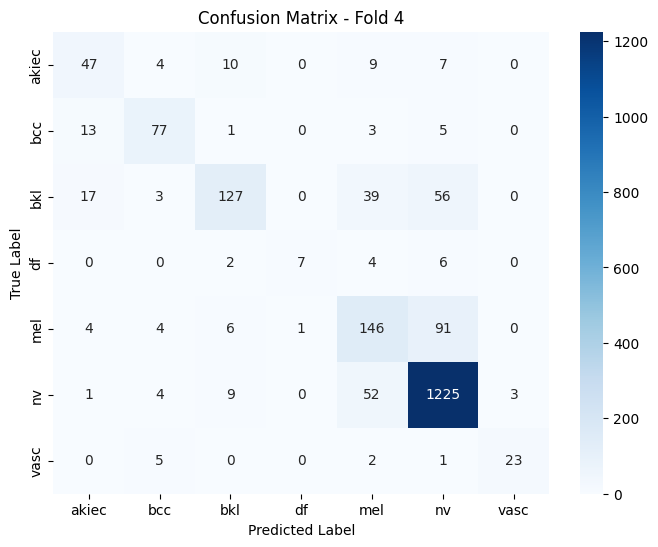

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp0_group

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.4000 Acc: 0.7538 | Val Loss: 0.2949 Acc: 0.8040
Epoch 2/50 - Train Loss: 0.1911 Acc: 0.8458 | Val Loss: 0.2155 Acc: 0.8409
Epoch 3/50 - Train Loss: 0.1390 Acc: 0.8792 | Val Loss: 0.2026 Acc: 0.8470
Epoch 4/50 - Train Loss: 0.0999 Acc: 0.9034 | Val Loss: 0.1991 Acc: 0.8510
Epoch 5/50 - Train Loss: 0.0737 Acc: 0.9314 | Val Loss: 0.1946 Acc: 0.8672
Epoch 6/50 - Train Loss: 0.0505 Acc: 0.9461 | Val Loss: 0.2068 Acc: 0.8616
Epoch 7/50 - Train Loss: 0.0399 Acc: 0.9599 | Val Loss: 0.2303 Acc: 0.8556
Epoch 8/50 - Train Loss: 0.0322 Acc: 0.9654 | Val Loss: 0.2355 Acc: 0.8601
Epoch 9/50 - Train Loss: 0.0276 Acc: 0.9705 | Val Loss: 0.2305 Acc: 0.8525
Epoch 10/50 - Train Loss: 0.0241 Acc: 0.9735 | Val Loss: 0.2311 Acc: 0.8601
Epoch 11/50 - Train Loss: 0.0232 Acc: 0.9746 | Val Loss: 0.2922 Acc: 0.8510
Epoch 12/50 - Train Loss: 0.0298 Acc: 0.9701 | Val Loss: 0.3067 A

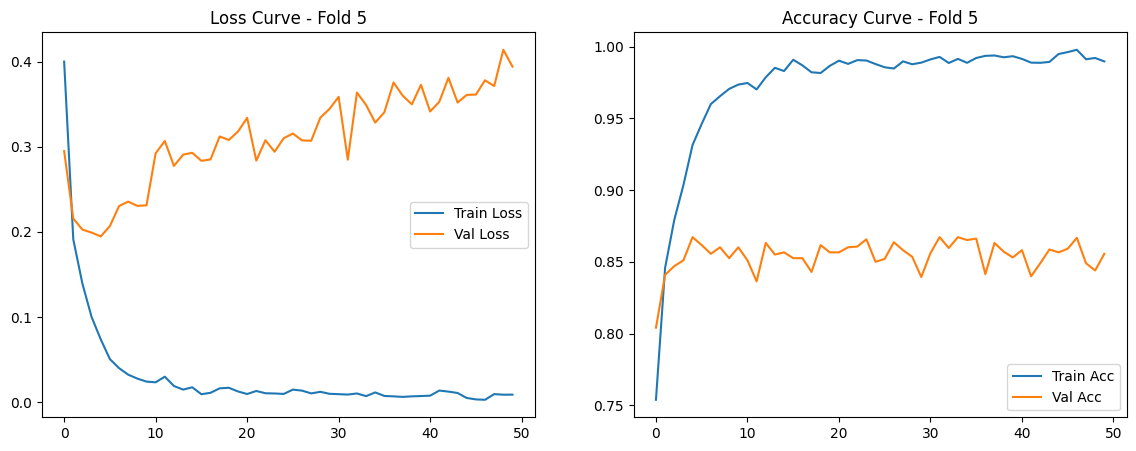

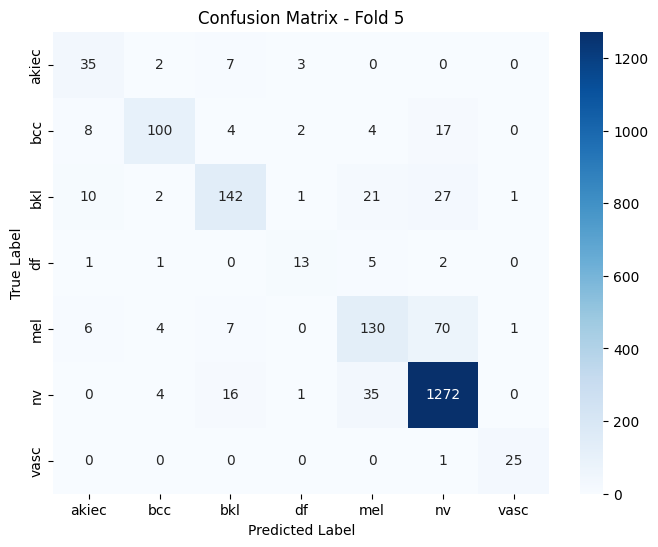

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp0_group

ALHAMDULILLAH, EKSPERIMEN basdeline SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [8]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 0: ConvNeXt Baseline + Focal Loss Group")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_Baseline(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN basdeline SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [9]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
results_path = "results_exp0_group"
csv_files = glob.glob(os.path.join(results_path, "exp0_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 0 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP0_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP0_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 0 (STATISTIK 5-FOLD)
Mean Accuracy : 0.8483 ± 0.0173
Mean Macro F1 : 0.7258 ± 0.0293
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.644845,0.643622,0.628921
bcc,0.786963,0.744354,0.763686
bkl,0.769028,0.662922,0.701096
df,0.833846,0.498360,0.602328
mel,0.619956,0.610932,0.613719
nv,0.912878,0.943638,0.927815
vasc,0.906784,0.795779,0.843116
macro avg,0.782043,0.699944,0.725812
weighted avg,0.849067,0.848300,0.845112



[INFO] Laporan final telah disimpan di: results_exp0_group/EXP0_FINAL_SUMMARY_STATISTICS.csv
